In [4]:
import numpy as np
import scipy.stats as ss
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

C:\Users\swana\AppData\Local\Temp\ipykernel_16152\1790852537.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x, semicircle, 'r-', lw=2.5, label = 'Semicircle Law (approx)', color = 'blue')


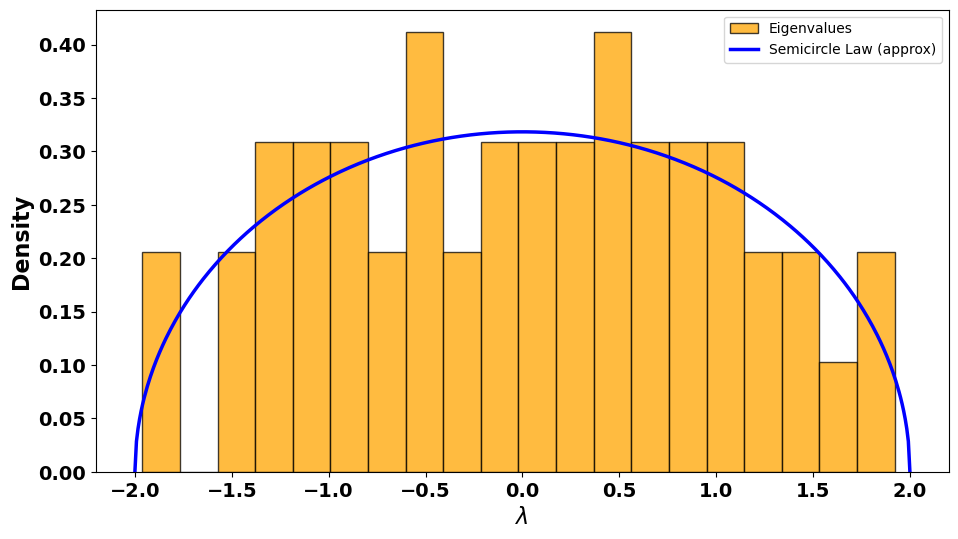

In [5]:
def random_symmetric_bernoulli(n):
    #Generate the upper triangle section in the matrix, including the diagonal, by sampling from the symmetric bern dist.
    upper = 2*np.random.binomial(1,p=0.5, size = (n,n))-1
    #We do 2X - 1 because X takes values of 1 and 0, so 2X-1 takes vales of 1 and -1 so symmetric about 0
    #Above code makes an nxn matrix of random entries from dist - then we take upper triangular part
    A = np.triu(upper) + np.triu(upper, k=1).T
    #This adds the upper triangular section including diagonal, to the transpose of it not including the diagonal
    #This creates a wigner matrix A
    return A

n = 50 #5000
A = random_symmetric_bernoulli(n)
l1 = np.linalg.eigvalsh(A)

plt.figure(figsize = (11,6))
plt.hist(l1/np.sqrt(n), bins = 20, density = True, alpha = 0.75, color = 'orange', edgecolor = 'black', label = 'Eigenvalues')

#Histogram of eigenvalues done
#Let us overlay the Wigner semicircle

x = np.linspace(-2,2, 500)
semicircle = (1/(2*np.pi)) * np.sqrt(4-x**2)
plt.plot(x, semicircle, 'r-', lw=2.5, label = 'Semicircle Law (approx)', color = 'blue')

#alpha is the opacity of the plot - makes it lighter and darker
#Now, to add all the titles and stuff:


plt.xlabel('Eigenvalue')
plt.ylabel('Density')
plt.legend()
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.xlabel(r'$\lambda$', fontsize=16, fontweight='bold')
plt.ylabel('Density', fontsize=16, fontweight='bold')
#Done, now show:

plt.show()

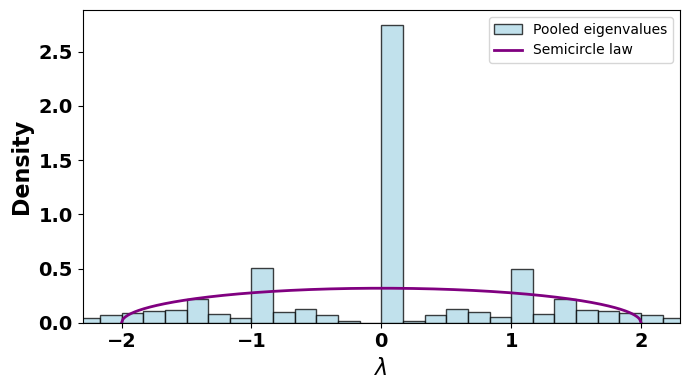

In [ ]:

def semicircle_density(x):
    """Function generates the Semicircle Law line overlay on the distribution."""
    return np.sqrt(np.maximum(0, 4 - x**2)) / (2*np.pi)

def centred_er_matrix(n, p):
    G = nx.erdos_renyi_graph(n, p)
    A = nx.adjacency_matrix(G).toarray().astype(float)
    J = np.ones((n, n))
    I = np.eye(n)
    H = (A - p * (J - I)) / np.sqrt(n * p * (1 - p))
    return H

def er_graph_spectrum_data(p, m, n=300, bins=30, plot=True):
    """We work out the eigenvalues for all m ER graphs and add them to one list, as well as calculating empirical moments. """
    all_eigs = []
    moments1 = []
    moments2 = []
    moments4 = []
    moments6 = []

    J = np.ones((n, n))
    I = np.eye(n)

    for _ in range(m):
        #for each iteration, we create an erdos renyi graph, and work out the eigenvalues of the normalised scaled matrix, then add them to a list
        eigs = np.linalg.eigvalsh(centred_er_matrix(n,p))
        all_eigs.extend(eigs)
        #Next, we add the mean of (eigs^2) to the list moments2, and the same with moments 4 and moments 6
        
        moments1.append(np.mean(eigs))
        moments2.append(np.mean(eigs**2))
        moments4.append(np.mean(eigs**4))
        moments6.append(np.mean(eigs**6))

    all_eigs = np.array(all_eigs)
    #adding all the eigenvalues to one final array
    # Histogram data
    hist, edges = np.histogram(all_eigs, bins=bins, range=(-2.5, 2.5), density=True)
    centres = 0.5*(edges[:-1] + edges[1:])
    widths = np.diff(edges)
    semi_vals = semicircle_density(centres)


    #making a dictionary for all the calculated values
    results = {
        "all_eigs": all_eigs,
        "m2_mean": np.mean(moments2), #We now take the mean of a list of moments2 in which we have one calculated moment from each of the M iterations. By taking the mean of this, we effectively get an estimator for the expectation
        "m4_mean": np.mean(moments4),
        "m6_mean": np.mean(moments6),
        "m2_error": abs(np.mean(moments2) - 1),
        "m4_error": abs(np.mean(moments4) - 2),
        "m6_error": abs(np.mean(moments6) - 5),
        "hist": hist,
        "centres": centres,
        "semi_vals": semi_vals,
        "m1_mean": np.mean(moments1),
        "m1_error": abs(np.mean(moments1) - 0)
    }

    if plot:
        x = np.linspace(-2, 2, 400)
        plt.figure(figsize=(7,4))
        plt.hist(all_eigs, bins=bins, range=(-2.5, 2.5), density=True,
                 alpha=0.75, color='lightblue', edgecolor='black', label='Pooled eigenvalues')
        plt.plot(x, semicircle_density(x), lw=2, color='purple', label='Semicircle law')
        plt.xticks(fontsize=14, fontweight='bold')
        plt.yticks(fontsize=14, fontweight='bold')
        plt.xlabel(r'$\lambda$', fontsize=16, fontweight='bold')
        plt.ylabel('Density', fontsize=16, fontweight='bold')
        plt.xlim(-2.3, 2.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return results


res = er_graph_spectrum_data(p=0.002, m=50, n=500, bins=30, plot=True)

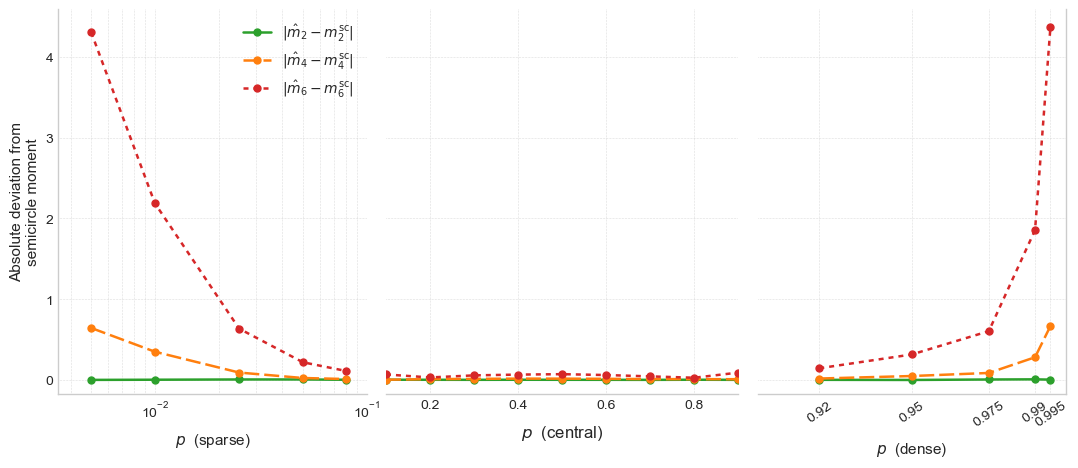

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

def empirical_moments_from_eigs(eigs, max_k=6):
    return [np.mean(eigs**k) for k in range(1, max_k + 1)]

def moment_deviation_vs_p(p_values, n=300, trials=50, max_k=6):
    semicircle_moments = {1: 0, 2: 1, 3: 0, 4: 2, 5: 0, 6: 5}
    avg_moments = {k: [] for k in range(1, max_k + 1)}
    deviations = {k: [] for k in range(1, max_k + 1)}
    
    
    for p in p_values:
        trial_moments = {k: [] for k in range(1, max_k + 1)}
        for _ in range(trials):
            H = centred_er_matrix(n, p)
            eigs = np.linalg.eigvalsh(H)
            moments = empirical_moments_from_eigs(eigs, max_k=max_k)
            for k in range(1, max_k + 1):
                trial_moments[k].append(moments[k - 1])
        for k in range(1, max_k + 1):
            avg_m = np.mean(trial_moments[k])
            avg_moments[k].append(avg_m)
            deviations[k].append(abs(avg_m - semicircle_moments[k]))

    return avg_moments, deviations


# p grids at different sparsity, then merge them together.
p_left = np.array([0.005, 0.01, 0.025, 0.05, 0.08])
p_mid = np.arange(0.1, 1.0, 0.1)          
p_right = np.array([0.92, 0.95, 0.975, 0.99, 0.995])
all_p = np.concatenate([p_left, p_mid, p_right])
avg_moments, deviations = moment_deviation_vs_p(all_p, n=300, trials=50, max_k=6)

n_l, n_m = len(p_left), len(p_mid)
def split(arr):
    a = np.array(arr)
    return a[:n_l], a[n_l:n_l + n_m], a[n_l + n_m:]

# figure
fig = plt.figure(figsize=(13, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.4, 1.6, 1.4], wspace=0.06, figure=fig)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[2], sharey=ax1)

moments_to_plot = [2, 4, 6]
colors = {2: '#2ca02c', 4: '#ff7f0e', 6: '#d62728'}
dashes = {2: (None, None), 4: (6, 2), 6: (2, 2)}

for k in moments_to_plot:
    yl, ym, yr = split(deviations[k])
    lbl = rf'$|\hat{{m}}_{k} - m_{k}^{{\rm sc}}|$'
    kw  = dict(color=colors[k], marker='o', markersize=5, linewidth=1.8, dashes=dashes[k])
    ax1.plot(p_left, yl, label=lbl, **kw)
    ax2.plot(p_mid, ym, **kw)
    ax3.plot(p_right, yr, **kw)
#scales
ax1.set_xscale('log')
ax1.set_xlim(p_left[0] * 0.7, 0.1)
ax2.set_xlim(0.1, 0.9)
ax2.set_xticks([0.2, 0.4, 0.6, 0.8])
ax3.set_xlim(0.9, 1.0)
ax3.set_xticks([0.92, 0.95, 0.975, 0.99, 0.995])

ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'.rstrip('0').rstrip('.')))
ax3.tick_params(axis='x', labelrotation=35)

all_devs = np.concatenate([np.array(deviations[k]) for k in moments_to_plot])
global_max = all_devs.max()
ax1.set_ylim(bottom=-0.04*global_max)

plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)


for ax in (ax1, ax2, ax3):
    ax.grid(True, which='both', ls=':', lw=0.4, alpha=0.5, color='grey')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.tick_params(labelsize=10)

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax2.tick_params(left=False)
ax3.tick_params(left=False)

ax1.set_xlabel(r'$p$(sparse)', fontsize=11, labelpad=8)
ax2.set_xlabel(r'$p$(central)', fontsize=12, labelpad=8)
ax3.set_xlabel(r'$p$(dense)', fontsize=11, labelpad=8)
ax1.set_ylabel('Absolute deviation from\nsemicircle moment', fontsize=11)

ax1.legend(fontsize=10, loc='upper right', framealpha=0.85, edgecolor='#ccc', fancybox=False)
plt.savefig('unified_spectral_moments.png', dpi=300, bbox_inches='tight')
plt.show()
